In this tutorial, we show how L2G detects target objects in the image.

### Setup
Let's start by loading some pre-requisites:

In [1]:
import os, sys

from pathlib import Path
import numpy as np
from matplotlib.patches import ConnectionPatch
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))

print("Project root added:", PROJECT_ROOT)

# -------------------------
# Device selection
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    print(f"using device: {device}")
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True

Project root added: /home/qifan/L2G
using device: cuda


### Model Loading

We load the DINOv3 ViT-L model:

In [2]:
REPO_DIR = "../dinov3"
MODEL_NAME = "dinov3_vitl16"
MODEL_PATH = "checkpoints/dinov3/dinov3_vitl16_pretrain_lvd1689m-8aa4cbdd.pth"

MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}

model  = torch.hub.load(REPO_DIR, model=MODEL_NAME, source='local', weights=MODEL_PATH)
model.to(device)
model.eval()  

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-23): 24 x SelfAttentionBlock(
      (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm)

We load the SAM2 model:

In [3]:
from sam2.build_sam import build_sam2
from utils.sam_utils import load_object_tokens

model_sam2 = build_sam2("configs/sam2.1/sam2.1_hiera_l.yaml", "../checkpoints/SAM/sam2.1_hiera_large.pt", device=device, n_objects=20)
model_sam2.eval()

#Injecting object tokens (Augmented SAM)
load_object_tokens(
    model_sam2,
    "../checkpoints/Object_tokens_RoboTools",
    device,
)

# ---- build predictor ----
from sam2.sam2_image_predictor import SAM2ImagePredictor
predictor = SAM2ImagePredictor(model_sam2)


##############n_objects: 20
found 20 files
[ok] loaded object 000001
[ok] loaded object 000002
[ok] loaded object 000003
[ok] loaded object 000004
[ok] loaded object 000005
[ok] loaded object 000006
[ok] loaded object 000007
[ok] loaded object 000008
[ok] loaded object 000009
[ok] loaded object 000010
[ok] loaded object 000011
[ok] loaded object 000012
[ok] loaded object 000013
[ok] loaded object 000014
[ok] loaded object 000015
[ok] loaded object 000016
[ok] loaded object 000017
[ok] loaded object 000018
[ok] loaded object 000019
[ok] loaded object 000020
Done. Merged 20 objects into (20, 2, 256)
All object ids loaded.


Loading adapter and Perception Model:

In [4]:
from adapter import load_pe_adapter
from utils.build import build_pe

pe_adapter = load_pe_adapter("../checkpoints/Adapter/RoboTools_Adapter.pt", device)
model_pe, preprocess_pe = build_pe(device)
model_pe.eval()

Loading PE model...
CLIP configs: ['PE-Core-G14-448', 'PE-Core-L14-336', 'PE-Core-B16-224']
Missing keys for loading model: []
Unexpected keys for loading model: []
model_pe.image_size: 336


CLIP(
  (token_embedding): Embedding(49408, 1024)
  (transformer): Transformer(
    (resblocks): ModuleList(
      (0-23): 24 x ResidualAttentionBlock(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
        )
        (ls_1): Identity()
        (ls_2): Identity()
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (drop_path1): Identity()
        (drop_path2): Identity()
        (mlp): Sequential(
          (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
          (gelu): GELU(approximate='none')
          (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
    )
  )
  (ln_final): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (ln_pre)

### Data Loading

Sample the template images:

In [5]:
!python ../tools/sample_templates.py --n 8 --datasets RoboTools

Done. Saved to: /home/qifan/L2G/data/Templates/RoboTools_8


Load the template images:

In [6]:
from utils.data import load_left_groups
from utils.build import build_left_batch_all

mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225] , device=device).view(1,3,1,1)
IMAGE_SIZE = 768
PATCH_SIZE = 16
MASK_FG_THRESHOLD = 0.5

import yaml
def load_config(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

cfg = load_config(os.path.join("../L2G_configs","RoboTools.yaml"))


left_groups, NUM_OBJECTS, SEQ_LEN = load_left_groups(
    Path(os.path.join("../data/Templates/RoboTools_8", "rgb")),
    Path(os.path.join("../data/Templates/RoboTools_8", "mask"))
)



(left_pairs_all, left_images_all, left_masks_all,
sel_left_all, left_vecs_all, H1_all, W1_all, left_cls_all, left_pe_feats_all,left_fg_mean_all) = build_left_batch_all(
    groups=left_groups,
    SEQ_LEN=SEQ_LEN,
    device=device,
    IMAGE_SIZE=IMAGE_SIZE,
    PATCH_SIZE=PATCH_SIZE,
    mean=mean,
    std=std,
    model=model,
    cfg=cfg,
    MASK_FG_THRESHOLD=MASK_FG_THRESHOLD,
    model_pe=model_pe,
    preprocess_pe=preprocess_pe,
    pe_adapter=pe_adapter,
)

##### Template 1 ##### The shape of feat_l: torch.Size([20, 1024, 48, 48])
##### Template 2 ##### The shape of feat_l: torch.Size([20, 1024, 48, 48])
##### Template 3 ##### The shape of feat_l: torch.Size([20, 1024, 48, 48])
##### Template 4 ##### The shape of feat_l: torch.Size([20, 1024, 48, 48])
##### Template 5 ##### The shape of feat_l: torch.Size([20, 1024, 48, 48])
##### Template 6 ##### The shape of feat_l: torch.Size([20, 1024, 48, 48])
##### Template 7 ##### The shape of feat_l: torch.Size([20, 1024, 48, 48])
##### Template 8 ##### The shape of feat_l: torch.Size([20, 1024, 48, 48])


### Processing query image

In [7]:
from utils.data import load_rgb
from Candidate import process_one_right_image_all

def resize_transform(img: Image.Image, image_size=IMAGE_SIZE, patch_size=PATCH_SIZE):
    """Resize image to (IMAGE_SIZE, proportional width) snapped to patch multiples; return tensor in [0,1]."""
    w, h = img.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(img, (h_patches * patch_size, w_patches * patch_size)))

scene_id = 1
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp"}
image_right_dir = Path("../demo/Query_RoboTools/") / f"{scene_id:06d}" / "rgb"
right_image_list = sorted([p for p in image_right_dir.iterdir() if p.suffix.lower() in IMG_EXT])
assert len(right_image_list) > 0, f"No right images found in {image_right_dir}"

for right_path in right_image_list:
    print(f"\n===== Processing Query image: {right_path.name} =====")
    # ---- Load RIGHT image and compute per-axis scale back to original pixels ----
    right_img_np = np.array(load_rgb(right_path))
    predictor.set_image(right_img_np)
    image_right = load_rgb(right_path)
    image_right_name = right_path.name
    right_resized = resize_transform(image_right).to(device)  # (3,Hr,Wr)
    Hr, Wr = right_resized.shape[-2], right_resized.shape[-1]
    print(f"hr={Hr}, Wr={Wr}")
    scale_right_x = image_right.width  / Wr
    scale_right_y = image_right.height / Hr
    right_norm = (right_resized.unsqueeze(0) - mean) / std
    print("right_norm.shape:",right_norm.shape)
    # ---- Query features ----
    with torch.inference_mode():
        out_r = model.get_intermediate_layers(
            right_norm,
            n=range(MODEL_TO_NUM_LAYERS[MODEL_NAME]),
            reshape=True,
            norm=True
        )
        feat_r = out_r[-1].squeeze(0).detach()  # (C, H2, W2)
    feat_r = F.normalize(feat_r, p=2, dim=0)        # (C, H2, W2)
    C, H2, W2 = feat_r.shape
    all_points_per_object = {b: [] for b in range(NUM_OBJECTS)}
    all_scores_per_object = {b: [] for b in range(NUM_OBJECTS)}

    all_points_per_object, all_scores_per_object = process_one_right_image_all(
        image_right=image_right,
        image_right_name=image_right_name,
        scale_right_x=scale_right_x,
        scale_right_y=scale_right_y,
        W2=W2,
        feat_r=feat_r,
        predictor=predictor,
        device=device,
        PATCH_SIZE=PATCH_SIZE,
        IMAGE_SIZE=IMAGE_SIZE,
        mean=mean,
        std=std,
        left_pairs_all=left_pairs_all,
        sel_left_all=sel_left_all,
        left_vecs_all=left_vecs_all,
        H1_all=H1_all,
        W1_all=W1_all,
        M_TARGET=10,
        S1_THR=0,
        model=model,
        model_pe=model_pe,
        preprocess_pe=preprocess_pe,
        pe_adapter=pe_adapter,
        left_cls_all = left_cls_all,
        left_pe_feats_all=left_pe_feats_all,
        left_fg_mean_all = left_fg_mean_all,
        cfg=cfg,
        TOP_DELTA=0.01,
        dedup_rounding=1,
    )



===== Processing Query image: 00000.png =====
hr=768, Wr=1360
right_norm.shape: torch.Size([1, 3, 768, 1360])
feat_r.shape: torch.Size([1024, 48, 85])
[Right=00000.png] [1/20] 000000.png: unique candidates = 89
[Right=00000.png] [2/20] 000000.png: unique candidates = 72
[Right=00000.png] [3/20] 000000.png: unique candidates = 59
[Right=00000.png] [4/20] 000000.png: unique candidates = 16
[Right=00000.png] [5/20] 000000.png: unique candidates = 26
[Right=00000.png] [6/20] 000000.png: unique candidates = 40
[Right=00000.png] [7/20] 000000.png: unique candidates = 17
[Right=00000.png] [8/20] 000000.png: unique candidates = 55
[Right=00000.png] [9/20] 000000.png: unique candidates = 78
[Right=00000.png] [10/20] 000000.png: unique candidates = 49
[Right=00000.png] [11/20] 000000.png: unique candidates = 12
[Right=00000.png] [12/20] 000000.png: unique candidates = 48
[Right=00000.png] [13/20] 000000.png: unique candidates = 35
[Right=00000.png] [14/20] 000000.png: unique candidates = 22
[Ri

### Post-processing

In [8]:
# ========= Post-processing =========
avg_score_all = {}
for b in list(all_scores_per_object.keys()):
    scores = all_scores_per_object[b]           # np.ndarray or list
    pts    = all_points_per_object[b]           # np.ndarray or list

    pts = np.asarray(pts, dtype=np.float32).reshape(-1, 2)      # (n,2)
    scores = np.asarray(scores, dtype=np.float32).reshape(-1)   # (n,)
    if scores.size == 0:
        avg_score_all[b] = 0.0
        all_points_per_object[b] = np.empty((0, 2), dtype=np.float32)
        all_scores_per_object[b] = np.empty((0,), dtype=np.float32)
        continue
    avg_score = float(scores.mean())
    avg_score_all[b] = avg_score
    if avg_score < 0:
        all_points_per_object[b] = np.empty((0, 2), dtype=np.float32)
        all_scores_per_object[b] = np.empty((0,), dtype=np.float32)
        continue
    keep = scores >= 0
    if not np.any(keep):
        all_points_per_object[b] = np.empty((0, 2), dtype=np.float32)
        all_scores_per_object[b] = np.empty((0,), dtype=np.float32)
        continue
    P = pts[keep]       # (m,2)
    S = scores[keep]    # (m,)
    m = P.shape[0]     

    # Deduplication (preserving the first occurrence of each point)
    uniq_P, uniq_idx = np.unique(P, axis=0, return_index=True)
    order = np.sort(uniq_idx)              # Preserve the order of first occurrence
    P = P[order]
    S = S[order]
    m = P.shape[0]
    if m == 0:
        all_points_per_object[b] = np.empty((0, 2), dtype=np.float32)
        all_scores_per_object[b] = np.empty((0,), dtype=np.float32)
        continue
    # Filtering and Farthest Point Sampling (FPS) 
    k_half = (m + 1) // 2     
    top_idx = np.argsort(-S)[:k_half]  
    P_top = P[top_idx]
    S_top = S[top_idx]
    MAX_DIST = 330.0
    #print(f"{b+1}_S_top:",S_top)
    seed = int(np.argmax(S_top))
    selected = [seed]
    min_dists = np.linalg.norm(P_top - P_top[seed], axis=1)   # (k_half,)
    min_dists[seed] = -np.inf

    while len(selected) < 4:
        nxt = int(np.argmax(min_dists))
        cur_dist = min_dists[nxt]
        if not np.isfinite(cur_dist):
            break
        if cur_dist > MAX_DIST:
            min_dists[nxt] = -np.inf   
            continue
        selected.append(nxt)
        d_new = np.linalg.norm(P_top - P_top[nxt], axis=1)
        min_dists = np.minimum(min_dists, d_new)
        min_dists[selected] = -np.inf
    sel_idx = np.array(selected, dtype=np.int64)
    P_sel = P_top[sel_idx]
    S_sel = S_top[sel_idx]
    all_points_per_object[b] = P_sel.astype(np.float32, copy=False)   # (k',2)
    all_scores_per_object[b] = S_sel.astype(np.float32, copy=False)   # (k',)

### Save the results

In [9]:
from utils.sam_utils import postprocess_mask_preserve_format
from utils.build import tight_bbox_from_mask, pe_feature_from_pil
import json

scene_results = []
for b, pts in all_points_per_object.items():
    if len(pts) == 0:
        continue

    point_coords = np.array(pts, dtype=np.float32)              # (N,2)
    point_coords = np.unique(point_coords, axis=0)
    point_labels = np.ones((len(point_coords),), dtype=np.int32)
    point_coords_used = point_coords

    predict_kwargs = dict(
        point_coords=point_coords_used,
        point_labels=point_labels,
        multimask_output=False,
    )


    predict_kwargs["Object_id"] = b + 1

    masks_final, scores_final, logits_final = predictor.predict(**predict_kwargs)

    mask_to_save = masks_final[0] if masks_final.ndim == 3 else masks_final
    mask_to_save = postprocess_mask_preserve_format(mask_to_save, point_coords, radius=6)
    image_to_save = right_img_np

    # === Write the results of object (b) on the current query image into scene_results ===
    _m2d = (mask_to_save > 0).astype(np.uint8)
    _ltbr = tight_bbox_from_mask(_m2d)
    left_feat_pe_final = left_pe_feats_all[0][b]
    left_feat_pe_final = left_feat_pe_final.to(device)
    if _ltbr is not None:
        crop_right_final = image_right.crop(_ltbr).convert("RGB")
        right_feat_pe_final = pe_feature_from_pil(crop_right_final, model_pe, preprocess_pe, pe_adapter, device)
        score_final = float(torch.dot(left_feat_pe_final, right_feat_pe_final).item())
        x0, y0, x1, y1 = map(int, _ltbr)
        coco_bbox = [x0, y0, int(x1 - x0), int(y1 - y0)]  # COCO [x,y,w,h]
        scene_results.append({
            "file_name": f"{scene_id:06d}/rgb/{right_path.name}",
            "category_id": int(b + 1), 
            "bbox": coco_bbox,
            "score": score_final, 
            "image_width": int(image_right.width),
            "image_height": int(image_right.height)
        })
out_json_path = Path(f"../Output/RoboTools_demo/{scene_id:06d}/demo.json")
out_json_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_json_path, "w", encoding="utf-8") as f:
    json.dump(scene_results, f, ensure_ascii=False)

### Show the detection boxes of the image

Showing bbox...


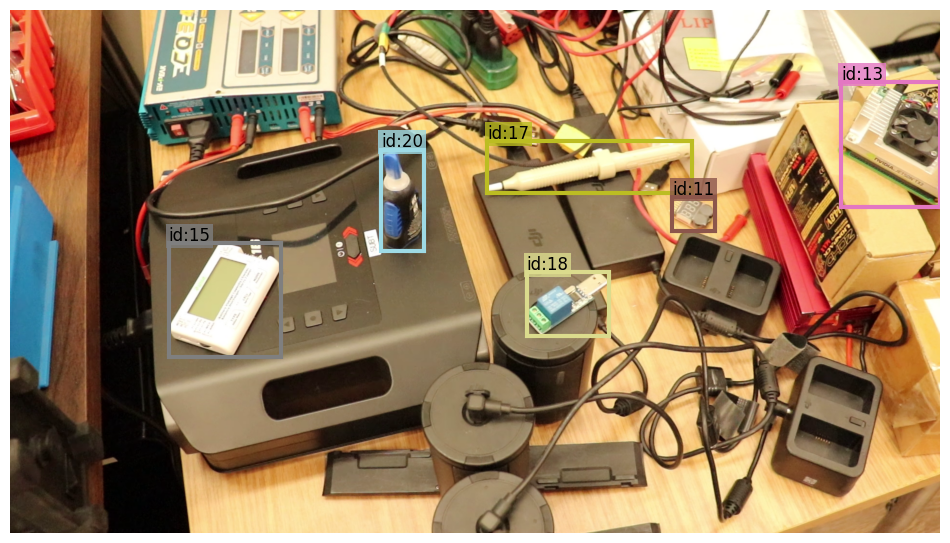

In [10]:
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

JSON_PATH = Path(f"../Output/RoboTools_demo/{scene_id:06d}/demo.json")  # Update if needed
with open(JSON_PATH, "r") as f:
    predictions = json.load(f)
preds_by_image = defaultdict(list)

for pred in predictions:
    preds_by_image[pred["file_name"]].append(pred)

IMG_ROOT = Path("../demo/Query_RoboTools")  # Modify to your actual root

def build_color_map(category_ids):
    """
    Assign a consistent color for each category_id.
    Uses matplotlib's tab20 colormap.
    """
    unique_ids = sorted(set(category_ids))
    cmap = plt.get_cmap("tab20", max(len(unique_ids), 1))

    color_map = {}
    for idx, cid in enumerate(unique_ids):
        color_map[cid] = cmap(idx % cmap.N)

    return color_map

all_category_ids = [p["category_id"] for p in predictions]
CID2COLOR = build_color_map(all_category_ids)

def draw_bboxes_on_image(
    image_path: Path,
    annotations: list,
    cid2color: dict,
    show_score: bool = False,
    save_path: Path = None,
):
    """
    Draw bounding boxes on a single image.

    Parameters:
    - image_path: Path to the image file
    - annotations: List of prediction dictionaries for that image
    - cid2color: Dictionary mapping category_id to color
    - show_score: Whether to display prediction score
    - save_path: If provided, saves the output image
    """
    # Load image
    image = Image.open(image_path).convert("RGB")
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(image)
    ax.axis("off")
    for ann in annotations:
        cid = ann["category_id"]
        x, y, w, h = ann["bbox"]  # COCO format: [x, y, width, height]
        color = cid2color.get(cid, (1, 0, 0, 1))
        # Create rectangle patch
        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=3,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)
        # Build label string
        label = f"id:{cid}"
        if show_score and "score" in ann:
            label += f"  s={ann['score']:.2f}"
        # Draw label text with colored background
        ax.text(
            x,
            max(0, y - 5),
            label,
            fontsize=12,
            color="black",
            bbox=dict(
                facecolor=color,
                alpha=0.8,
                pad=2,
                edgecolor="none",
            ),
        )

    # Save image if requested
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
        print(f"Saved to {save_path}")

    plt.show()
first_image_key = list(preds_by_image.keys())[0]
image_path = IMG_ROOT / first_image_key
score_threshold = 0.8 
filtered_annotations = [
    ann for ann in preds_by_image[first_image_key]
    if ("score" not in ann) or (ann["score"] >= score_threshold)
]
print("Showing bbox...")
draw_bboxes_on_image(
    image_path=image_path,
    annotations=filtered_annotations,
    cid2color=CID2COLOR,
    show_score=False,
)